# DBGSOM vs. MiniSom — Comparison

This notebook compares DBGSOM (`SomVQ`) with [justglowing/minisom](https://github.com/JustGlowing/minisom) on the scikit-learn Digits dataset.

## Algorithm Overview

| Property         | DBGSOM                                                              | MiniSom                         |
| ---------------- | ------------------------------------------------------------------- | ------------------------------- |
| Learning rule    | **Batch** (all samples per epoch)                                   | **Online** (sample-by-sample)   |
| Grid topology    | Rectangular (grows dynamically)                                     | Rectangular / hexagonal (fixed) |
| Growth criterion | Neuron added where accumulated error exceeds growing threshold (GT) | —                               |
| Initialization   | 4 neurons (chosen from training samples)                            | Random or PCA                   |
| API              | **sklearn-compatible** (`fit` / `transform` / `predict`)            | Custom API (`train` / `winner`) |
| Neighborhood     | Gaussian decay over epochs                                          | Gaussian decay over iterations  |

> **Same topology, different sizing:** Both DBGSOM and MiniSom use a rectangular grid. The key difference is that DBGSOM determines the grid size and form dynamically: a new neuron is inserted adjacent all neurons which's error exceeds the growing threshold GT. MiniSom requires the grid dimensions to be fixed before training.

**Fair comparison:** Because DBGSOM grows dynamically, we first train DBGSOM to determine its final neuron count `N`, then configure MiniSom with a `ceil(sqrt(N)) × floor(sqrt(N))` grid — giving both models an approximately equal neuron budget.


## Imports


In [29]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

## Dataset

We use the scikit-learn **Digits** dataset: 1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9).


In [30]:
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
print(
    f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes"
)

Dataset: 1797 samples, 64 features, 10 classes


## Step 1 — Train DBGSOM

DBGSOM starts with 4 neurons and grows until `max_neurons` is reached or convergence is detected.


In [79]:
som_db = SomVQ(
    n_iter=300,
    spreading_factor=0.6,
    max_neurons=100,
    convergence_iter=15,
    sigma_end=1,
    verbose=True,
    random_state=42,
)

t0 = time.perf_counter()
som_db.fit(X)
t_db = time.perf_counter() - t0

n_neurons_db = len(som_db.neurons_)
print(f"DBGSOM: {n_neurons_db} neurons after {t_db:.2f}s")

 59%|█████▊    | 176/300 [00:00<00:00, 668.89 epochs/s]

DBGSOM: 43 neurons after 0.28s


## Step 2 — Train MiniSom

MiniSom uses a fixed rectangular grid. We choose `side = ceil(sqrt(N))` so the total neuron count is close to DBGSOM's final count.

MiniSom's `train_batch` uses the same batch update principle as DBGSOM (weights updated after all samples), making it the most comparable training mode.


In [82]:
side = math.ceil(math.sqrt(n_neurons_db))
side2 = math.floor(math.sqrt(n_neurons_db))
n_neurons_ms = side * side2

som_ms = MiniSom(
    x=side,
    y=side,
    input_len=X.shape[1],
    sigma=0.5 * np.sqrt(side**2),
    learning_rate=0.5,
    random_seed=42,
)

# train_batch: batch update — closest to DBGSOM's learning rule
# num_iteration = epochs × n_samples for comparable training effort
t0 = time.perf_counter()
som_ms.train_batch(X, num_iteration=200 * len(X))
t_ms = time.perf_counter() - t0

print(f"MiniSom:  {n_neurons_ms} neurons ({side}×{side2} grid) after {t_ms:.2f}s")

MiniSom:  42 neurons (7×6 grid) after 13.44s


## Step 3 — Metrics Comparison

> **Note on topographic error:** Both libraries report a _topographic error_, but they measure different things:
>
> - **MiniSom** uses the standard Kohonen definition: fraction of samples whose 1st and 2nd BMU are _not adjacent_ in the grid.
> - **DBGSOM** (`topographic_error_`) stores the same Kohonen-style metric during training. `topographic_function()` implements the stricter Villmann et al. (1997) measure based on graph distances.
>
> The values are comparable at a high level (lower = better topology preservation), but not numerically identical.


In [83]:
qe_db = som_db.calculate_quantization_error(X)
qe_ms = som_ms.quantization_error(X)

te_db = som_db.topographic_error_
te_ms = som_ms.topographic_error(X)

metrics = pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error",
            "Topographic error",
        ],
        "DBGSOM": [
            f"{t_db:.2f}",
            n_neurons_db,
            f"{qe_db:.4f}",
            f"{te_db:.4f}",
        ],
        "MiniSom": [
            f"{t_ms:.2f}",
            n_neurons_ms,
            f"{qe_ms:.4f}",
            f"{te_ms:.4f}",
        ],
    }
).set_index("Metric")

metrics

,DBGSOM,MiniSom
Metric,,
Training time (s),0.28,13.44
Neuron count,43,42
Quantization error,5.2441,5.9497
Topographic error,0.0490,0.0623


## Step 4 — Visualization

Both SOMs are projected into the same 2D PCA space (PCA fitted on the data `X`), so neuron positions are directly comparable. Color encodes the mean distance to neighboring neurons (normalized to [0, 1]) — equivalent to a U-Matrix, darker = larger inter-neuron distances = cluster boundary.

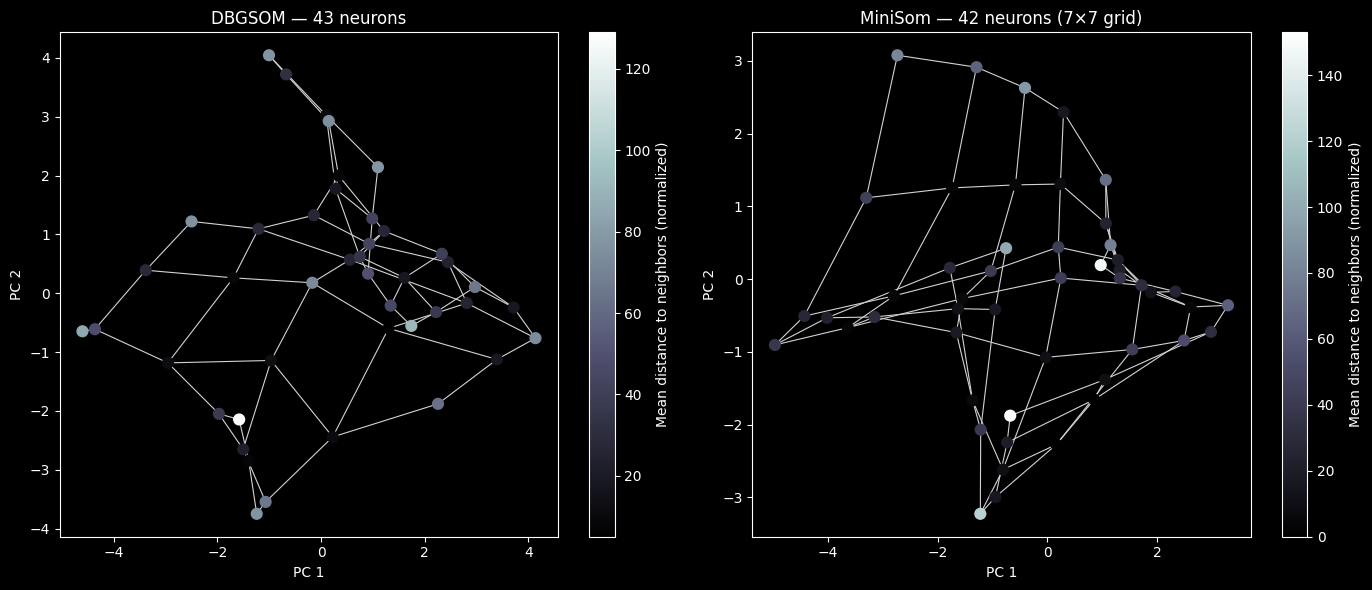

In [84]:
from sklearn.decomposition import PCA

# Fit PCA on the data so both SOMs share the same coordinate system
pca = PCA(n_components=2, random_state=42)
pca.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- DBGSOM ---
weights_db_2d = pca.transform(som_db.weights_)
avg_dist = np.array(
    [som_db.som_.nodes[n].get("hit_count", 0.0) for n in som_db.neurons_]
)
avg_dist_norm = avg_dist
# avg_dist_norm = avg_dist / avg_dist.max()

ax = axes[0]
ax.set_title(f"DBGSOM — {n_neurons_db} neurons", fontsize=12)

node_pos = dict(zip(som_db.neurons_, weights_db_2d))
for u, v in som_db.som_.edges():
    x0, y0 = node_pos[u]
    x1, y1 = node_pos[v]
    ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=0.8, zorder=1)

sc = ax.scatter(
    weights_db_2d[:, 0],
    weights_db_2d[:, 1],
    c=avg_dist_norm,
    cmap="bone",
    # vmin=0,
    # vmax=1,
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Mean distance to neighbors (normalized)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- MiniSom ---
ms_weights = som_ms.get_weights()  # shape: (side, side, n_features)
ms_weights_flat = ms_weights.reshape(-1, X.shape[1])  # shape: (side*side, n_features)
weights_ms_2d = pca.transform(ms_weights_flat)

# umatrix = som_ms.distance_map()  # (side, side), normalized to [0, 1]
umatrix = som_ms.activation_response(X)  # (side, side), normalized to [0, 1]

umatrix_flat = umatrix.reshape(-1)

ax = axes[1]
ax.set_title(f"MiniSom — {n_neurons_ms} neurons ({side}×{side} grid)", fontsize=12)

# Draw rectangular grid edges
for i in range(side):
    for j in range(side):
        idx = i * side + j
        if i + 1 < side:
            nb = (i + 1) * side + j
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < side:
            nb = i * side + (j + 1)
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_ms_2d[:, 0],
    weights_ms_2d[:, 1],
    c=umatrix_flat,
    cmap="bone",
    # vmin=0,
    # vmax=1,
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Mean distance to neighbors (normalized)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

plt.tight_layout()
plt.show()

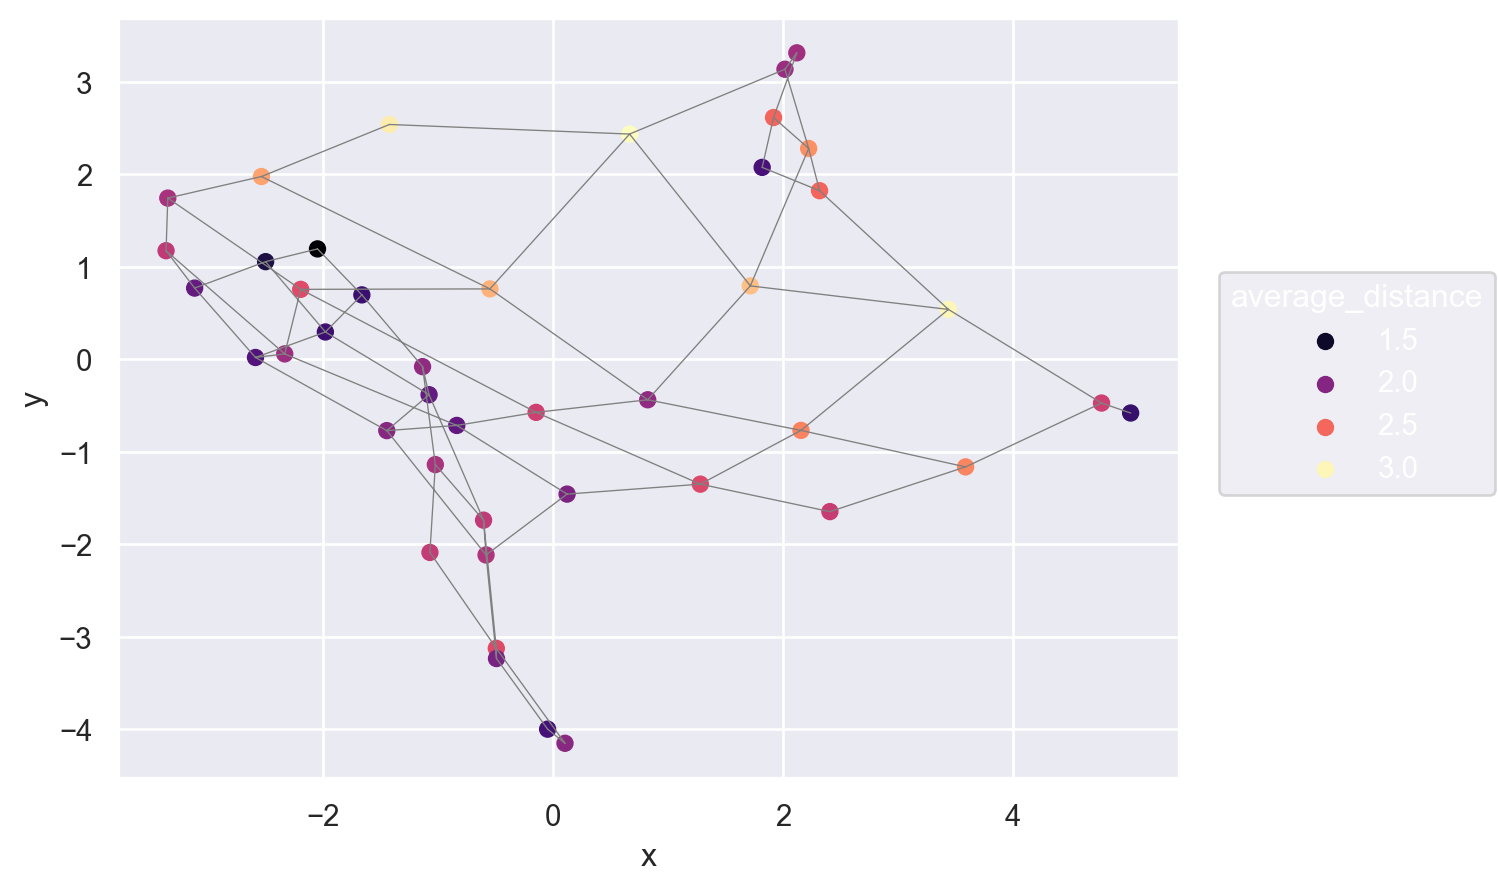

In [86]:
som_db.plot(layout="pca", color="average_distance", palette="magma")

## Summary

| Aspect                    | DBGSOM                                     | MiniSom                                            |
| ------------------------- | ------------------------------------------ | -------------------------------------------------- |
| **Best for**              | Unknown optimal map size; automatic sizing | Quick experiments; well-understood grid size       |
| **Hyperparameter burden** | `spreading_factor`, `max_neurons`          | Grid dimensions `x`, `y`, `learning_rate`, `sigma` |
| **sklearn pipelines**     | Yes (`fit` / `transform` / `predict`)      | No (custom API)                                    |
| **Growing overhead**      | Yes (error tracking + insertion per epoch) | No                                                 |
| **Grid topology**         | Rectangular, size determined automatically | Rectangular / hexagonal, fixed upfront             |

DBGSOM trades off a slightly higher training cost for the ability to adapt the map size automatically, which is beneficial when the ideal number of neurons is not known in advance.
